# 08F — Model comparison M1–M5

**Project:** Barranquilla LST/SUHI modeling  
**Purpose:** Compare the final GitHub model sequence under the fixed 2016–2025 protocol.

Models compared:

- M1 — U-Net baseline
- M2 — SE U-Net
- M3 — ConvLSTM U-Net
- M4 — ConvLSTM-SE U-Net
- M5 — T3-Climate ConvLSTM-SE U-Net  
  Internal development identifier: **M5B**

In [14]:
# ============================================================
# CELDA 1 — Imports and global configuration
# ============================================================

from pathlib import Path
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

EXPECTED_TRAIN_YEARS = {2016, 2017, 2018, 2019}
EXPECTED_VALIDATION_YEARS = {2020, 2021, 2022}
EXPECTED_TEST_YEARS = {2023, 2024, 2025}

MODEL_SPECS = [
    {"model_key": "M1_UNet", "public_label": "M1 — U-Net baseline", "aliases": ["M1_UNet", "M1", "unet_baseline"]},
    {"model_key": "M2_SE_UNet", "public_label": "M2 — SE U-Net", "aliases": ["M2_SE_UNet", "M2", "se_unet"]},
    {"model_key": "M3_ConvLSTM_UNet", "public_label": "M3 — ConvLSTM U-Net", "aliases": ["M3_ConvLSTM_UNet", "M3", "convlstm_unet"]},
    {"model_key": "M4_ConvLSTM_SE_UNet", "public_label": "M4 — ConvLSTM-SE U-Net", "aliases": ["M4_ConvLSTM_SE_UNet", "M4", "convlstm_se_unet"]},
    {"model_key": "M5_T3Climate_ConvLSTM_SE_UNet", "public_label": "M5 — T3-Climate ConvLSTM-SE U-Net", "aliases": ["M5_T3Climate_ConvLSTM_SE_UNet", "M5", "M5B", "T3Climate", "t3_climate", "delta_t2m_delta_radiation"]},
]

REQUIRED_SPLIT_COLS = ["model", "best_epoch", "split", "loss", "mae", "rmse", "bias", "r2", "n_valid_pixels"]
REQUIRED_YEAR_COLS = ["model", "split", "target_year", "loss", "mae", "rmse", "bias", "r2", "n_valid_pixels"]

In [15]:
# ============================================================
# CELDA 2 — Resolución robusta de carpeta de resultados
# ============================================================

# Este comparador necesita encontrar la carpeta donde 08A–08E guardaron
# sus métricas. En Colab, el fallo más frecuente no es que falten los CSV,
# sino que Google Drive no esté montado en esta sesión.

from pathlib import Path
import os

# ------------------------------------------------------------
# 2.1 Montaje seguro de Google Drive
# ------------------------------------------------------------
def ensure_drive_available():
    mydrive = Path("/content/drive/MyDrive")
    if mydrive.exists():
        print("Google Drive ya parece montado:", mydrive)
        return

    try:
        from google.colab import drive
        print("Montando Google Drive en /content/drive ...")
        drive.mount("/content/drive")
    except Exception as e:
        print("No fue posible montar Drive automáticamente.")
        print("Detalle:", repr(e))
        print("Si estás en Colab, ejecuta manualmente:")
        print("from google.colab import drive")
        print("drive.mount('/content/drive', force_remount=True)")

ensure_drive_available()

# ------------------------------------------------------------
# 2.2 Utilidades de búsqueda controlada
# ------------------------------------------------------------
def path_depth(p: Path) -> int:
    return len(p.parts)


def iter_existing_roots():
    candidates = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/Shareddrives"),
        Path("/content/drive"),
        Path.cwd(),
    ]
    seen = set()
    for root in candidates:
        if root.exists() and str(root) not in seen:
            seen.add(str(root))
            yield root


def list_first_level(root: Path, max_items: int = 50):
    print(f"\nContenido visible en {root}:")
    if not root.exists():
        print("  [no existe]")
        return
    shown = 0
    for p in sorted(root.iterdir()):
        if p.is_dir():
            print(" -", p.name)
            shown += 1
            if shown >= max_items:
                print(" ...")
                break


def resolve_base_out() -> Path:
    # 1) Permitir ruta manual si el usuario la define.
    env = os.environ.get("MODULE08_OUT_DIR")
    if env:
        p = Path(env)
        print("MODULE08_OUT_DIR from environment:", p)
        print("Exists:", p.exists())
        if p.exists():
            return p
        raise FileNotFoundError(
            f"MODULE08_OUT_DIR está definido pero no existe: {p}"
        )

    # 2) Ruta canónica esperada.
    canonical = Path(
        "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/"
        "07_models/t3_climate/module08_independent_2016_2025"
    )
    print("Canonical BASE_OUT:", canonical)
    print("Canonical exists:", canonical.exists())
    if canonical.exists():
        return canonical

    # Diagnóstico temprano: mostrar si el proyecto se ve en MyDrive.
    mydrive = Path("/content/drive/MyDrive")
    list_first_level(mydrive)

    # 3) Buscar carpeta exacta module08_independent_2016_2025 en Drive.
    found = []
    target_name = "module08_independent_2016_2025"

    for root in iter_existing_roots():
        print("\nBuscando", target_name, "dentro de", root)
        for dirpath, dirnames, filenames in os.walk(root):
            p = Path(dirpath)

            # Evitar basura y reducir recorridos muy profundos.
            if ".Trash" in p.parts or ".shortcut-targets-by-id" in p.parts:
                # No anulamos shortcut-targets en caso de que el proyecto esté allí;
                # se deja comentado intencionalmente por reproducibilidad.
                pass

            if p.name == target_name:
                found.append(p)

            # Profundidad suficiente para MyDrive/proyecto/07_models/t3_climate/module08...
            if path_depth(p) - path_depth(root) > 12:
                dirnames[:] = []

    found = sorted(set(found), key=lambda x: len(str(x)))
    if found:
        print("\nCandidate module08 output directories:")
        for f in found:
            print(" -", f)
        return found[0]

    # 4) Buscar por CSV de evaluación de M5, por si el nombre base cambió.
    eval_csv_dirs = []
    for root in iter_existing_roots():
        print("\nBuscando CSV de evaluación dentro de", root)
        for dirpath, dirnames, filenames in os.walk(root):
            p = Path(dirpath)
            low_path = str(p).lower()
            low_files = [fn.lower() for fn in filenames]

            has_eval_csv = any(fn.endswith(".csv") and "eval" in fn for fn in low_files)
            likely_m08 = (
                "module08" in low_path or
                "m5_t3climate" in low_path or
                "m1_unet" in low_path or
                "m2_se_unet" in low_path or
                "m3_convlstm" in low_path or
                "m4_convlstm" in low_path
            )

            if has_eval_csv and likely_m08:
                eval_csv_dirs.append(p)

            if path_depth(p) - path_depth(root) > 12:
                dirnames[:] = []

    if eval_csv_dirs:
        # En estructura esperada: BASE_OUT/model/evaluation/*.csv
        base_candidates = []
        for p in eval_csv_dirs:
            # p = .../<model>/evaluation
            if p.name == "evaluation":
                base_candidates.append(p.parent.parent)
            else:
                base_candidates.append(p.parent)

        base_candidates = sorted(set(base_candidates), key=lambda x: len(str(x)))
        print("\nCandidate BASE_OUT directories inferred from evaluation CSVs:")
        for b in base_candidates[:10]:
            print(" -", b)
        return base_candidates[0]

    # 5) Fallo explícito, con instrucción manual.
    raise FileNotFoundError(
        "No pude resolver BASE_OUT. Esto suele significar que Drive no está montado "
        "o que las salidas se guardaron en una carpeta distinta.\n\n"
        "Solución manual antes de correr este notebook:\n"
        "import os\n"
        "os.environ['MODULE08_OUT_DIR'] = '/content/drive/MyDrive/.../module08_independent_2016_2025'"
    )


BASE_OUT = resolve_base_out()
COMPARE_OUT = BASE_OUT / "comparison_M1_M5"
for sub in ["metadata", "tables", "figures"]:
    (COMPARE_OUT / sub).mkdir(parents=True, exist_ok=True)

print("\nBASE_OUT resolved to:")
print(BASE_OUT)
print("\nCOMPARE_OUT:")
print(COMPARE_OUT)


Google Drive ya parece montado: /content/drive/MyDrive
Canonical BASE_OUT: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025
Canonical exists: True

BASE_OUT resolved to:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025

COMPARE_OUT:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/comparison_M1_M5


In [16]:
# ============================================================
# CELDA 3 — Helper functions for robust CSV discovery
# ============================================================

def normalize_text(s: str) -> str:
    return str(s).lower().replace("-", "_").replace(" ", "_")

def find_model_dir(base_out: Path, spec: dict) -> Path | None:
    key = spec["model_key"]
    aliases = [normalize_text(a) for a in spec.get("aliases", [])]

    exact = base_out / key
    if exact.exists():
        return exact

    if base_out.exists():
        for child in sorted(base_out.iterdir()):
            if not child.is_dir():
                continue
            name = normalize_text(child.name)
            if normalize_text(key) in name or any(a in name for a in aliases):
                if (child / "evaluation").exists():
                    return child

    if base_out.exists():
        csvs = list(base_out.rglob("*.csv"))
        for csv in csvs:
            name = normalize_text(csv.name)
            parent_text = normalize_text(str(csv.parent))
            if ("eval" in name or "evaluation" in parent_text):
                if normalize_text(key) in name or normalize_text(key) in parent_text:
                    return csv.parent.parent
                if any(a in name or a in parent_text for a in aliases):
                    return csv.parent.parent

    return None

def candidate_csvs_for_model(model_dir: Path | None, kind: str) -> list[Path]:
    if model_dir is None or not model_dir.exists():
        return []

    csvs = []
    for d in [model_dir / "evaluation", model_dir]:
        if d.exists():
            csvs.extend(sorted(d.glob("*.csv")))

    if not csvs:
        csvs = sorted(model_dir.rglob("*.csv"))

    kind_tokens = {
        "split": ["split"],
        "year": ["year", "target_year", "by_year", "by_target_year"],
    }[kind]

    out = []
    for f in csvs:
        name = normalize_text(f.name)
        if "eval" not in name and "metrics" not in name:
            continue
        if any(tok in name for tok in kind_tokens):
            out.append(f)

    return sorted(set(out))

def read_csv_safely(path: Path) -> pd.DataFrame | None:
    try:
        return pd.read_csv(path)
    except Exception as e:
        warnings.warn(f"Could not read CSV: {path} | {repr(e)}")
        return None

def choose_best_csv(candidates: list[Path], required_cols: list[str]):
    diagnostics = []
    valid = []
    for p in candidates:
        df = read_csv_safely(p)
        if df is None:
            diagnostics.append({"path": str(p), "valid": False, "reason": "read_error"})
            continue

        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            diagnostics.append({
                "path": str(p),
                "valid": False,
                "reason": "missing_columns",
                "missing_columns": ",".join(missing),
                "columns": ",".join(df.columns),
            })
            continue

        diagnostics.append({"path": str(p), "valid": True, "reason": "ok", "n_rows": len(df)})
        valid.append((p, df))

    if not valid:
        return None, None, diagnostics

    valid = sorted(valid, key=lambda item: (0 if item[0].name.startswith("08") else 1, len(str(item[0])), str(item[0])))
    return valid[0][0], valid[0][1], diagnostics

def standardize_model_column(df: pd.DataFrame, model_key: str) -> pd.DataFrame:
    df = df.copy()
    df["model"] = model_key
    return df

In [17]:
# ============================================================
# CELDA 4 — Inventory and validation of available outputs
# ============================================================

inventory_rows = []
diagnostic_rows = []
split_tables = []
year_tables = []

for spec in MODEL_SPECS:
    key = spec["model_key"]
    model_dir = find_model_dir(BASE_OUT, spec)
    eval_dir = model_dir / "evaluation" if model_dir is not None else None

    split_candidates = candidate_csvs_for_model(model_dir, "split") if model_dir is not None else []
    year_candidates  = candidate_csvs_for_model(model_dir, "year") if model_dir is not None else []

    split_csv, split_df, split_diag = choose_best_csv(split_candidates, REQUIRED_SPLIT_COLS)
    year_csv, year_df, year_diag = choose_best_csv(year_candidates, REQUIRED_YEAR_COLS)

    for d in split_diag:
        d["model_key"] = key
        d["kind"] = "split"
        diagnostic_rows.append(d)
    for d in year_diag:
        d["model_key"] = key
        d["kind"] = "year"
        diagnostic_rows.append(d)

    inventory_rows.append({
        "model_key": key,
        "public_label": spec["public_label"],
        "resolved_model_dir": str(model_dir) if model_dir is not None else None,
        "model_dir_exists": bool(model_dir.exists()) if model_dir is not None else False,
        "evaluation_dir_exists": bool(eval_dir.exists()) if eval_dir is not None else False,
        "n_split_candidates": len(split_candidates),
        "n_year_candidates": len(year_candidates),
        "selected_split_csv": str(split_csv) if split_csv is not None else None,
        "selected_year_csv": str(year_csv) if year_csv is not None else None,
        "split_valid": split_df is not None,
        "year_valid": year_df is not None,
    })

    if split_df is not None:
        split_df = standardize_model_column(split_df, key)
        split_tables.append(split_df[REQUIRED_SPLIT_COLS].copy())

    if year_df is not None:
        year_df = standardize_model_column(year_df, key)
        year_tables.append(year_df[REQUIRED_YEAR_COLS].copy())

inventory = pd.DataFrame(inventory_rows)
diagnostics = pd.DataFrame(diagnostic_rows)

display(inventory)
inventory.to_csv(COMPARE_OUT / "metadata" / "08F_evaluation_file_inventory_M1_M5.csv", index=False)

if len(diagnostics):
    diagnostics.to_csv(COMPARE_OUT / "metadata" / "08F_csv_diagnostics_M1_M5.csv", index=False)

missing = inventory.loc[~(inventory["split_valid"] & inventory["year_valid"])].copy()

if len(missing):
    print("Advertencia: hay modelos con salidas incompletas o inválidas.")
    display(missing[[
        "model_key", "resolved_model_dir", "split_valid", "year_valid",
        "selected_split_csv", "selected_year_csv"
    ]])

    print("\nDirectorio BASE_OUT usado:")
    print(BASE_OUT)

    print("\nPrimeros directorios encontrados bajo BASE_OUT:")
    if BASE_OUT.exists():
        for p in sorted(BASE_OUT.iterdir()):
            if p.is_dir():
                print(" -", p.name)

    raise FileNotFoundError(
        "No se encontraron CSV válidos para todos los modelos M1–M5. "
        "Revise el inventario mostrado y ejecute los notebooks faltantes."
    )

split_eval = pd.concat(split_tables, ignore_index=True)
year_eval = pd.concat(year_tables, ignore_index=True)

print("CSV válidos cargados correctamente.")
display(split_eval)
display(year_eval.head(12))

,model_key,public_label,resolved_model_dir,model_dir_exists,evaluation_dir_exists,n_split_candidates,n_year_candidates,selected_split_csv,selected_year_csv,split_valid,year_valid
0,M1_UNet,M1 — U-Net baseline,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M1_UNet,True,True,1,1,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M1_UNet/evaluation/08_eval_by_split_M1_UNet.csv,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M1_UNet/evaluation/08_eval_by_year_M1_UNet.csv,True,True
1,M2_SE_UNet,M2 — SE U-Net,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M2_SE_UNet,True,True,1,1,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M2_SE_UNet/evaluation/08_eval_by_split_M2_SE_UNet.csv,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M2_SE_UNet/evaluation/08_eval_by_year_M2_SE_UNet.csv,True,True
2,M3_ConvLSTM_UNet,M3 — ConvLSTM U-Net,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet,True,True,1,1,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet/evaluation/08_eval_by_split_M3_ConvLSTM_UNet.csv,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M3_ConvLSTM_UNet/evaluation/08_eval_by_year_M3_ConvLSTM_UNet.csv,True,True
3,M4_ConvLSTM_SE_UNet,M4 — ConvLSTM-SE U-Net,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M4_ConvLSTM_SE_UNet,True,True,1,1,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M4_ConvLSTM_SE_UNet/evaluation/08_eval_by_split_M4_ConvLSTM_SE_UNet.csv,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M4_ConvLSTM_SE_UNet/evaluation/08_eval_by_year_M4_ConvLSTM_SE_UNet.csv,True,True
4,M5_T3Climate_ConvLSTM_SE_UNet,M5 — T3-Climate ConvLSTM-SE U-Net,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M5_T3Climate_ConvLSTM_SE_UNet,True,True,1,1,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M5_T3Climate_ConvLSTM_SE_UNet/evaluation/08_eval_by_split_M5_T3Climate_ConvLSTM_SE_UN...,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/M5_T3Climate_ConvLSTM_SE_UNet/evaluation/08_eval_by_year_M5_T3Climate_ConvLSTM_SE_UNe...,True,True


CSV válidos cargados correctamente.


,model,best_epoch,split,loss,mae,rmse,bias,r2,n_valid_pixels
0,M1_UNet,8,train,0.143702,0.423533,0.546554,-0.158843,0.661395,12803928
1,M1_UNet,8,validation,0.124956,0.401673,0.504678,0.061212,0.730849,2551475
2,M1_UNet,8,test,0.185778,0.499629,0.620150,-0.176204,0.598296,2565780
3,M2_SE_UNet,16,train,0.144682,0.423012,0.549116,-0.171111,0.658212,12803928
4,M2_SE_UNet,16,validation,0.125370,0.402082,0.505591,0.044226,0.729875,2551475
5,M2_SE_UNet,16,test,0.191859,0.508549,0.630716,-0.191106,0.584490,2565780
6,M3_ConvLSTM_UNet,20,train,0.128641,0.401525,0.514837,-0.065963,0.699554,12803928
7,M3_ConvLSTM_UNet,20,validation,0.135201,0.429970,0.523735,0.151828,0.710139,2551475
8,M3_ConvLSTM_UNet,20,test,0.174441,0.479279,0.599513,-0.077921,0.624586,2565780
9,M4_ConvLSTM_SE_UNet,1,train,0.163436,0.454905,0.584652,-0.165401,0.612544,12803928


,model,split,target_year,loss,mae,rmse,bias,r2,n_valid_pixels
0,M1_UNet,train,2016,0.127290,0.397181,0.512462,-0.139854,0.633804,3208500
1,M1_UNet,train,2017,0.111373,0.368017,0.477598,0.008049,0.711579,3195756
2,M1_UNet,train,2018,0.153489,0.444032,0.565238,-0.196101,0.691640,3192906
3,M1_UNet,train,2019,0.182597,0.484817,0.620113,-0.307064,0.545767,3206766
4,M1_UNet,validation,2020,0.146972,0.437140,0.548518,-0.000797,0.658187,841746
5,M1_UNet,validation,2021,0.132434,0.413803,0.519469,0.010633,0.697521,854472
6,M1_UNet,validation,2022,0.095815,0.354646,0.440595,0.172773,0.765296,855257
7,M1_UNet,test,2023,0.286866,0.654477,0.776112,-0.623866,0.369157,855218
8,M1_UNet,test,2024,0.112944,0.371537,0.482359,-0.263029,0.663583,855263
9,M1_UNet,test,2025,0.157531,0.472882,0.564582,0.358237,0.597910,855299


In [18]:
# ============================================================
# CELDA 5 — Protocol validation: years and split definitions
# ============================================================

year_eval["target_year"] = year_eval["target_year"].astype(int)

if 2026 in set(year_eval["target_year"].unique()):
    raise ValueError("Protocol violation: 2026 appears in evaluation outputs. It must be excluded.")

observed_by_split = {
    split: set(year_eval.loc[year_eval["split"] == split, "target_year"].unique())
    for split in ["train", "validation", "test"]
}

expected_by_split = {
    "train": EXPECTED_TRAIN_YEARS,
    "validation": EXPECTED_VALIDATION_YEARS,
    "test": EXPECTED_TEST_YEARS,
}

protocol_rows = []
for split, expected in expected_by_split.items():
    observed = observed_by_split.get(split, set())
    protocol_rows.append({
        "split": split,
        "expected_years": sorted(expected),
        "observed_years": sorted(observed),
        "matches_expected": observed == expected,
    })

protocol_df = pd.DataFrame(protocol_rows)
display(protocol_df)
protocol_df.to_csv(COMPARE_OUT / "metadata" / "08F_protocol_validation_M1_M5.csv", index=False)

if not protocol_df["matches_expected"].all():
    raise ValueError("Protocol validation failed. Check target-year splits.")

print("Protocol validation passed: 2016–2025 only, with TEST = 2023–2025.")

,split,expected_years,observed_years,matches_expected
0,train,"[2016, 2017, 2018, 2019]","[2016, 2017, 2018, 2019]",True
1,validation,"[2020, 2021, 2022]","[2020, 2021, 2022]",True
2,test,"[2023, 2024, 2025]","[2023, 2024, 2025]",True


Protocol validation passed: 2016–2025 only, with TEST = 2023–2025.


In [19]:
# ============================================================
# CELDA 6 — Test ranking
# ============================================================

label_map = {spec["model_key"]: spec["public_label"] for spec in MODEL_SPECS}

split_eval["model_label"] = split_eval["model"].map(label_map)
year_eval["model_label"] = year_eval["model"].map(label_map)

test_rank = (
    split_eval.loc[split_eval["split"] == "test"]
    .copy()
    .sort_values(["rmse", "mae", "bias"], ascending=[True, True, True])
)

test_rank["rank_rmse"] = np.arange(1, len(test_rank) + 1)
test_rank = test_rank[[
    "rank_rmse", "model", "model_label", "best_epoch",
    "loss", "mae", "rmse", "bias", "r2", "n_valid_pixels"
]]

display(test_rank)

test_rank.to_csv(COMPARE_OUT / "tables" / "08F_test_ranking_M1_M5.csv", index=False)

,rank_rmse,model,model_label,best_epoch,loss,mae,rmse,bias,r2,n_valid_pixels
14,1,M5_T3Climate_ConvLSTM_SE_UNet,M5 — T3-Climate ConvLSTM-SE U-Net,13,0.099222,0.346874,0.449742,-0.073751,0.788729,2565780
8,2,M3_ConvLSTM_UNet,M3 — ConvLSTM U-Net,20,0.174441,0.479279,0.599513,-0.077921,0.624586,2565780
2,3,M1_UNet,M1 — U-Net baseline,8,0.185778,0.499629,0.620150,-0.176204,0.598296,2565780
5,4,M2_SE_UNet,M2 — SE U-Net,16,0.191859,0.508549,0.630716,-0.191106,0.584490,2565780
11,5,M4_ConvLSTM_SE_UNet,M4 — ConvLSTM-SE U-Net,1,0.216503,0.546599,0.672800,-0.284225,0.527192,2565780


In [20]:
# ============================================================
# CELDA 7 — Year-wise TEST diagnostics
# ============================================================

test_year = year_eval.loc[year_eval["split"] == "test"].copy()
test_year = test_year.sort_values(["target_year", "rmse"])

display(test_year[[
    "model", "model_label", "target_year",
    "mae", "rmse", "bias", "r2", "n_valid_pixels"
]])

for metric in ["rmse", "mae", "bias", "r2"]:
    pivot = test_year.pivot_table(
        index="target_year",
        columns="model_label",
        values=metric,
        aggfunc="first"
    )
    display(pivot)
    pivot.to_csv(COMPARE_OUT / "tables" / f"08F_test_year_{metric}_pivot_M1_M5.csv")

,model,model_label,target_year,mae,rmse,bias,r2,n_valid_pixels
47,M5_T3Climate_ConvLSTM_SE_UNet,M5 — T3-Climate ConvLSTM-SE U-Net,2023,0.376229,0.479200,-0.040293,0.759505,855218
27,M3_ConvLSTM_UNet,M3 — ConvLSTM U-Net,2023,0.566520,0.691461,-0.523738,0.499265,855218
7,M1_UNet,M1 — U-Net baseline,2023,0.654477,0.776112,-0.623866,0.369157,855218
17,M2_SE_UNet,M2 — SE U-Net,2023,0.674479,0.792004,-0.651154,0.343057,855218
37,M4_ConvLSTM_SE_UNet,M4 — ConvLSTM-SE U-Net,2023,0.761583,0.869206,-0.736150,0.208742,855218
48,M5_T3Climate_ConvLSTM_SE_UNet,M5 — T3-Climate ConvLSTM-SE U-Net,2024,0.328535,0.432491,-0.160186,0.729547,855263
28,M3_ConvLSTM_UNet,M3 — ConvLSTM U-Net,2024,0.328988,0.437366,-0.165742,0.723415,855263
8,M1_UNet,M1 — U-Net baseline,2024,0.371537,0.482359,-0.263029,0.663583,855263
18,M2_SE_UNet,M2 — SE U-Net,2024,0.372795,0.486535,-0.278825,0.657733,855263
38,M4_ConvLSTM_SE_UNet,M4 — ConvLSTM-SE U-Net,2024,0.469212,0.580992,-0.386155,0.511935,855263


model_label,M1 — U-Net baseline,M2 — SE U-Net,M3 — ConvLSTM U-Net,M4 — ConvLSTM-SE U-Net,M5 — T3-Climate ConvLSTM-SE U-Net
target_year,,,,,
2023,0.776112,0.792004,0.691461,0.869206,0.479200
2024,0.482359,0.486535,0.437366,0.580992,0.432491
2025,0.564582,0.573966,0.639409,0.514715,0.436033


model_label,M1 — U-Net baseline,M2 — SE U-Net,M3 — ConvLSTM U-Net,M4 — ConvLSTM-SE U-Net,M5 — T3-Climate ConvLSTM-SE U-Net
target_year,,,,,
2023,0.654477,0.674479,0.566520,0.761583,0.376229
2024,0.371537,0.372795,0.328988,0.469212,0.328535
2025,0.472882,0.478383,0.542331,0.409018,0.335859


model_label,M1 — U-Net baseline,M2 — SE U-Net,M3 — ConvLSTM U-Net,M4 — ConvLSTM-SE U-Net,M5 — T3-Climate ConvLSTM-SE U-Net
target_year,,,,,
2023,-0.623866,-0.651154,-0.523738,-0.736150,-0.040293
2024,-0.263029,-0.278825,-0.165742,-0.386155,-0.160186
2025,0.358237,0.356615,0.455670,0.269583,-0.020775


model_label,M1 — U-Net baseline,M2 — SE U-Net,M3 — ConvLSTM U-Net,M4 — ConvLSTM-SE U-Net,M5 — T3-Climate ConvLSTM-SE U-Net
target_year,,,,,
2023,0.369157,0.343057,0.499265,0.208742,0.759505
2024,0.663583,0.657733,0.723415,0.511935,0.729547
2025,0.597910,0.584433,0.484264,0.665802,0.760167


In [21]:
# ============================================================
# CELDA 8 — Key comparisons against baseline and spectral architecture
# ============================================================

def get_test_metric(model_key, metric):
    row = split_eval.loc[
        (split_eval["model"] == model_key) &
        (split_eval["split"] == "test")
    ]
    if len(row) != 1:
        return np.nan
    return float(row.iloc[0][metric])


comparisons = []

pairs = [
    (
        "M1_UNet",
        "M3_ConvLSTM_UNet",
        "Effect of explicit temporal memory"
    ),
    (
        "M1_UNet",
        "M4_ConvLSTM_SE_UNet",
        "Effect of ConvLSTM + SE over baseline"
    ),
    (
        "M4_ConvLSTM_SE_UNet",
        "M5_T3Climate_ConvLSTM_SE_UNet",
        "Effect of climate-radiative augmentation over M4"
    ),
    (
        "M1_UNet",
        "M5_T3Climate_ConvLSTM_SE_UNet",
        "Final M5 configuration versus baseline"
    ),
]

for ref, cand, description in pairs:
    row = {
        "comparison": description,
        "reference_model": ref,
        "candidate_model": cand,
    }

    for metric in ["rmse", "mae", "bias", "r2"]:
        ref_val = get_test_metric(ref, metric)
        cand_val = get_test_metric(cand, metric)

        row[f"reference_{metric}"] = ref_val
        row[f"candidate_{metric}"] = cand_val
        row[f"delta_{metric}"] = cand_val - ref_val

        if metric in ["rmse", "mae"]:
            row[f"relative_change_{metric}_pct"] = (
                100 * (cand_val - ref_val) / ref_val
            )

    comparisons.append(row)

key_comp = pd.DataFrame(comparisons)

display(key_comp)

key_comp.to_csv(
    COMPARE_OUT / "tables" / "08F_key_model_comparisons_M1_M5.csv",
    index=False
)

,comparison,reference_model,candidate_model,reference_rmse,candidate_rmse,delta_rmse,relative_change_rmse_pct,reference_mae,candidate_mae,delta_mae,relative_change_mae_pct,reference_bias,candidate_bias,delta_bias,reference_r2,candidate_r2,delta_r2
0,Effect of explicit temporal memory,M1_UNet,M3_ConvLSTM_UNet,0.62015,0.599513,-0.020637,-3.327763,0.499629,0.479279,-0.020350,-4.073045,-0.176204,-0.077921,0.098283,0.598296,0.624586,0.026291
1,Effect of ConvLSTM + SE over baseline,M1_UNet,M4_ConvLSTM_SE_UNet,0.62015,0.672800,0.052650,8.489858,0.499629,0.546599,0.046970,9.400930,-0.176204,-0.284225,-0.108021,0.598296,0.527192,-0.071104
2,Effect of climate-radiative augmentation over M4,M4_ConvLSTM_SE_UNet,M5_T3Climate_ConvLSTM_SE_UNet,0.67280,0.449742,-0.223058,-33.153652,0.546599,0.346874,-0.199725,-36.539579,-0.284225,-0.073751,0.210474,0.527192,0.788729,0.261537
3,Final M5 configuration versus baseline,M1_UNet,M5_T3Climate_ConvLSTM_SE_UNet,0.62015,0.449742,-0.170408,-27.478492,0.499629,0.346874,-0.152755,-30.573710,-0.176204,-0.073751,0.102453,0.598296,0.788729,0.190433


In [22]:
# ============================================================
# CELDA 9 — Export consolidated workbook
# ============================================================

split_eval_out = split_eval[REQUIRED_SPLIT_COLS + ["model_label"]].copy()
year_eval_out = year_eval[REQUIRED_YEAR_COLS + ["model_label"]].copy()

split_eval_out.to_csv(COMPARE_OUT / "tables" / "08F_eval_by_split_M1_M5.csv", index=False)
year_eval_out.to_csv(COMPARE_OUT / "tables" / "08F_eval_by_year_M1_M5.csv", index=False)

excel_path = COMPARE_OUT / "tables" / "08F_model_comparison_M1_M5_2016_2025.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    split_eval_out.to_excel(writer, sheet_name="eval_by_split", index=False)
    year_eval_out.to_excel(writer, sheet_name="eval_by_year", index=False)
    test_rank.to_excel(writer, sheet_name="test_ranking", index=False)
    key_comp.to_excel(writer, sheet_name="key_comparisons", index=False)
    protocol_df.to_excel(writer, sheet_name="protocol_validation", index=False)
    inventory.to_excel(writer, sheet_name="file_inventory", index=False)
    if len(diagnostics):
        diagnostics.to_excel(writer, sheet_name="csv_diagnostics", index=False)

print("Consolidated outputs saved to:")
print(COMPARE_OUT / "tables")
print("\nExcel workbook:")
print(excel_path)

Consolidated outputs saved to:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/comparison_M1_M5/tables

Excel workbook:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/comparison_M1_M5/tables/08F_model_comparison_M1_M5_2016_2025.xlsx


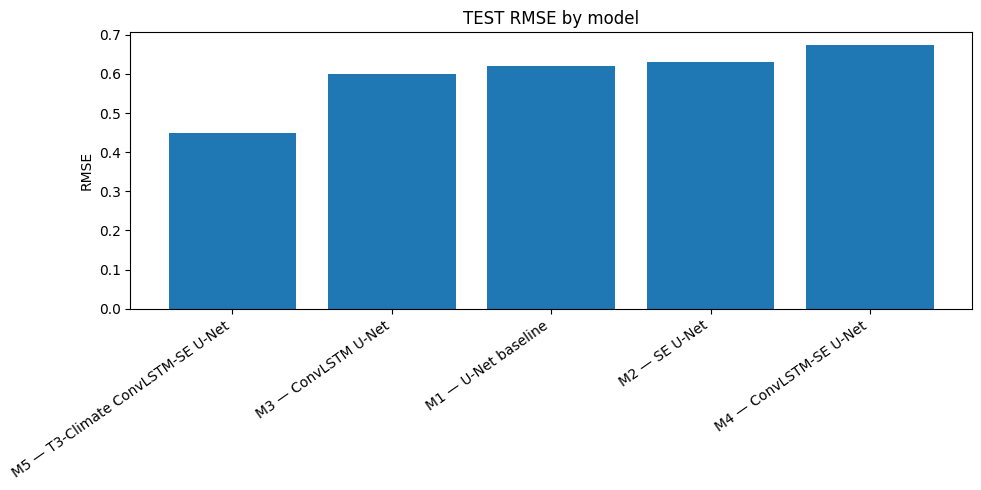

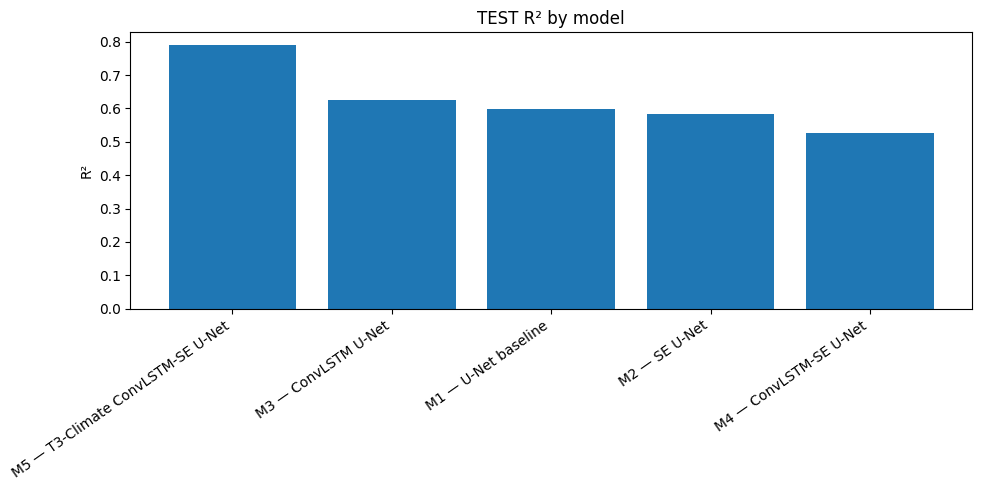

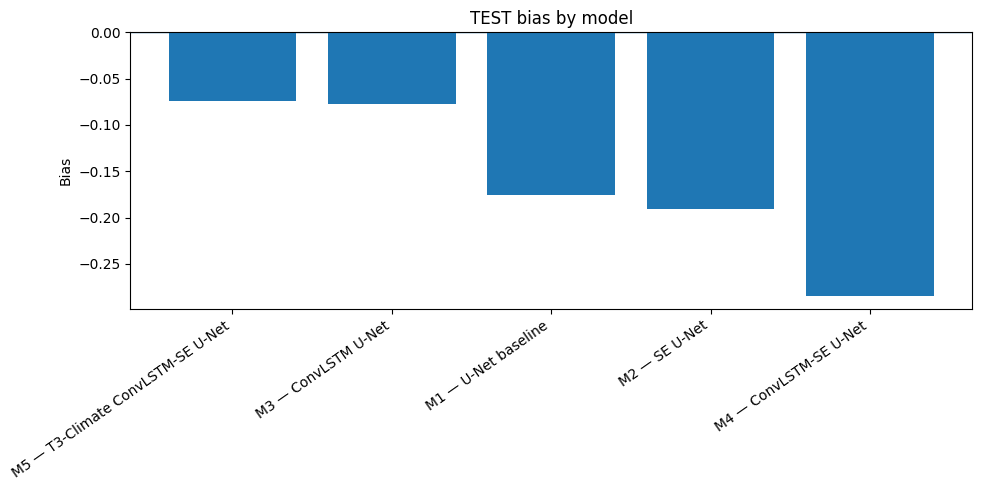

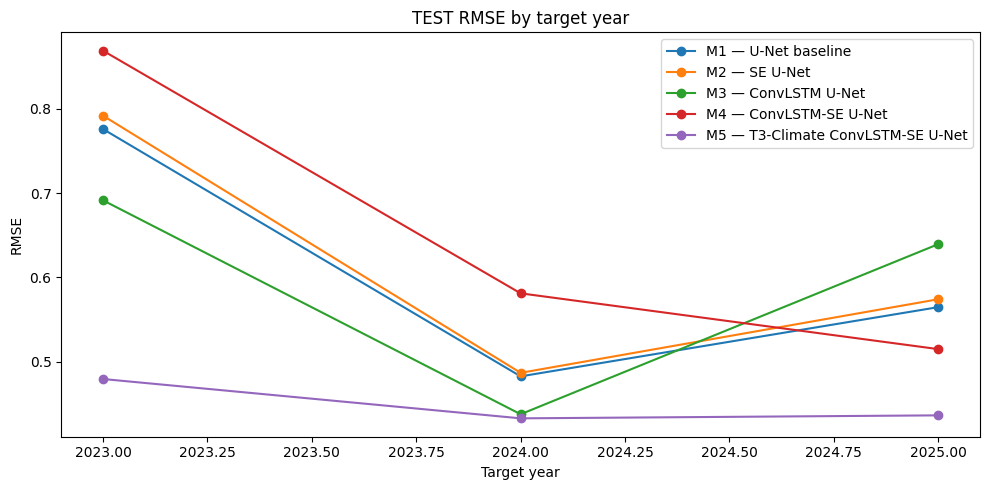

Figures saved to:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/comparison_M1_M5/figures


In [23]:
# ============================================================
# CELDA 10 — Figures
# ============================================================

fig_dir = COMPARE_OUT / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plot_df = test_rank.sort_values("rmse")
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_label"], plot_df["rmse"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("RMSE")
plt.title("TEST RMSE by model")
plt.tight_layout()
plt.savefig(fig_dir / "08F_test_rmse_by_model_M1_M5.png", dpi=200)
plt.show()

plot_df = test_rank.sort_values("r2", ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_label"], plot_df["r2"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("R²")
plt.title("TEST R² by model")
plt.tight_layout()
plt.savefig(fig_dir / "08F_test_r2_by_model_M1_M5.png", dpi=200)
plt.show()

plot_df = test_rank.copy()
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_label"], plot_df["bias"])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Bias")
plt.title("TEST bias by model")
plt.tight_layout()
plt.savefig(fig_dir / "08F_test_bias_by_model_M1_M5.png", dpi=200)
plt.show()

pivot_rmse = test_year.pivot_table(
    index="target_year", columns="model_label", values="rmse", aggfunc="first"
)
plt.figure(figsize=(10, 5))
for col in pivot_rmse.columns:
    plt.plot(pivot_rmse.index, pivot_rmse[col], marker="o", label=col)
plt.xlabel("Target year")
plt.ylabel("RMSE")
plt.title("TEST RMSE by target year")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "08F_test_rmse_by_year_M1_M5.png", dpi=200)
plt.show()

print("Figures saved to:")
print(fig_dir)

In [24]:
# ============================================================
# CELDA 11 — Final TEST evaluation summary
# ============================================================

best = test_rank.iloc[0].to_dict()

evaluation_summary = {
    "best_test_ranked_model": best["model"],
    "best_test_ranked_model_label": best["model_label"],
    "evaluation_basis": (
        "Final TEST ranking under the fixed 2016–2025 retrospective protocol. "
        "TEST results are reported only as final evaluation after validation-based "
        "checkpoint selection. TEST was not used for model training, checkpoint "
        "selection, hyperparameter tuning, or architectural selection."
    ),
    "metric_scale": (
        "Normalized LST scale. Physical-unit metrics in degrees Celsius are "
        "generated in 09_physical_unit_evaluation_and_exports.ipynb."
    ),
    "test_rmse_norm": float(best["rmse"]),
    "test_mae_norm": float(best["mae"]),
    "test_r2": float(best["r2"]),
    "test_bias_norm": float(best["bias"]),
    "test_n_valid_pixels": int(best["n_valid_pixels"]),
    "expected_train_years": sorted(EXPECTED_TRAIN_YEARS),
    "expected_validation_years": sorted(EXPECTED_VALIDATION_YEARS),
    "expected_test_years": sorted(EXPECTED_TEST_YEARS),
    "notes": [
        "The M5 public label corresponds internally to the T3-Climate ConvLSTM-SE U-Net configuration.",
        "M5 uses the T3 spectral sequence plus delta_t2m and delta_solar_radiation descriptors.",
        "The target year 2026 is excluded because it is not a complete annual period.",
        "This notebook summarizes normalized-scale model comparison. Celsius-scale evaluation is performed in Module 09."
    ]
}

summary_path = COMPARE_OUT / "metadata" / "08F_final_test_evaluation_summary_M1_M5.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_summary, f, indent=2, ensure_ascii=False)

print(json.dumps(evaluation_summary, indent=2, ensure_ascii=False))

print("\nFinal TEST evaluation summary saved to:")
print(summary_path)

{
  "best_test_ranked_model": "M5_T3Climate_ConvLSTM_SE_UNet",
  "best_test_ranked_model_label": "M5 — T3-Climate ConvLSTM-SE U-Net",
  "evaluation_basis": "Final TEST ranking under the fixed 2016–2025 retrospective protocol. TEST results are reported only as final evaluation after validation-based checkpoint selection. TEST was not used for model training, checkpoint selection, hyperparameter tuning, or architectural selection.",
  "metric_scale": "Normalized LST scale. Physical-unit metrics in degrees Celsius are generated in 09_physical_unit_evaluation_and_exports.ipynb.",
  "test_rmse_norm": 0.4497420901325347,
  "test_mae_norm": 0.3468737592101622,
  "test_r2": 0.7887288289416918,
  "test_bias_norm": -0.0737510806813239,
  "test_n_valid_pixels": 2565780,
  "expected_train_years": [
    2016,
    2017,
    2018,
    2019
  ],
  "expected_validation_years": [
    2020,
    2021,
    2022
  ],
  "expected_test_years": [
    2023,
    2024,
    2025
  ],
  "notes": [
    "The M5 publi